# Metabolomic signatures of lung cancer

In this activity, you will work with a metabolomics dataset of lung cancer cell lines. Your
goal is to explore the data, identify patterns that distinguish different lung cancer types,
and use machine learning to classify samples from their metabolomic profiles.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score,  mean_squared_error
import seaborn as sns # for data visualization

from sklearn.model_selection import KFold, GridSearchCV
from scipy.optimize import minimize 
from sklearn.preprocessing import StandardScaler

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier, AdaBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import VotingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from collections import Counter
from sklearn.utils import resample
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import xgboost as xgb
from sklearn.feature_selection import RFECV
from sklearn.model_selection import StratifiedKFold
import warnings
import shap

c:\Users\ibane\anaconda3\envs\compu2\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Read our csv


In [4]:
df_can = pd.read_csv('lung_metabolite.csv')

df_can.info()
df_can

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 170 entries, 0 to 169
Columns: 233 entries, depmap_id to C58:6 TAG
dtypes: float64(227), object(6)
memory usage: 309.6+ KB


,depmap_id,cell_line_display_name,lineage_1,lineage_2,lineage_3,lineage_5,lineage_6,lineage_4,2-aminoadipate,3-phosphoglycerate,...,C56:8 TAG,C56:7 TAG,C56:6 TAG,C56:5 TAG,C56:4 TAG,C56:3 TAG,C56:2 TAG,C58:8 TAG,C58:7 TAG,C58:6 TAG
0,ACH-000382,CORL24,Lung,Lung Neuroendocrine Tumor,Small Cell Lung Cancer,NaN,NaN,NaN,6.355282,5.925996,...,6.626914,6.840296,6.477311,6.577317,6.100430,5.948911,5.488192,6.735114,6.873852,6.525304
1,ACH-000187,CORL311,Lung,Lung Neuroendocrine Tumor,Small Cell Lung Cancer,NaN,NaN,NaN,6.007757,5.429262,...,5.919669,5.838518,6.033150,6.026209,6.216869,5.888160,5.830213,5.717243,5.707384,5.799696
2,ACH-000695,CORL47,Lung,Lung Neuroendocrine Tumor,Small Cell Lung Cancer,NaN,NaN,NaN,5.896787,5.562469,...,6.475107,6.162490,6.232128,6.004562,5.941130,5.736837,5.568404,6.366693,6.189653,6.355080
3,ACH-000743,CORL95,Lung,Lung Neuroendocrine Tumor,Small Cell Lung Cancer,NaN,NaN,NaN,5.924172,5.496766,...,5.917623,6.011277,6.061634,6.009789,5.728991,5.211672,5.377540,5.851722,5.569160,6.001461
4,ACH-000594,DMS153,Lung,Lung Neuroendocrine Tumor,Small Cell Lung Cancer,NaN,NaN,NaN,5.977402,5.846425,...,6.547328,6.172195,6.079922,6.080236,5.970876,5.848762,5.890081,6.172220,6.336906,6.100512
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165,ACH-000813,T3M10,Lung,Non-Small Cell Lung Cancer,Large Cell Lung Carcinoma,NSCLC Large Cell,NaN,NaN,5.931984,5.797560,...,6.074333,6.087892,6.266766,6.176254,6.220653,6.203956,6.134322,6.503731,6.114799,6.160238
166,ACH-000553,SQ1,Lung,Non-Small Cell Lung Cancer,Lung Squamous Cell Carcinoma,NSCLC Squamous,NaN,NaN,5.786616,6.033218,...,5.950516,5.925734,6.081680,6.507246,6.738147,6.703344,6.487318,5.908497,5.983071,6.153465
167,ACH-000563,EBC1,Lung,Non-Small Cell Lung Cancer,Lung Squamous Cell Carcinoma,NSCLC Squamous,NaN,NaN,5.597010,5.557838,...,6.053566,6.703516,6.446724,6.400131,6.582091,6.235148,6.529355,6.810024,6.840226,6.981296
168,ACH-000769,LK2,Lung,Non-Small Cell Lung Cancer,Lung Squamous Cell Carcinoma,NSCLC Squamous,NaN,NaN,5.577334,5.830027,...,5.631971,5.311994,5.469874,5.415784,5.623638,5.623288,6.003752,5.223870,5.511518,5.139813


In [5]:
categorias = df_can['lineage_2'].unique()
print(categorias)

['Lung Neuroendocrine Tumor' 'Non-Small Cell Lung Cancer']


In [28]:
def evaluate_sfs_by_train_size(df, test_size=0.2):
    """
    Entrena un modelo SFS con un tamaño de test específico y devuelve las métricas.
    """
    # 1. Separar X e y
    X = df_can.drop(['depmap_id', 'cell_line_display_name', 'lineage_1', 
                 'lineage_2', 'lineage_3', 'lineage_4', 'lineage_5', 'lineage_6'], axis=1)
    y = df_can['lineage_2']
    
    # 2. División Dinámica
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=42)
    
    # 3. Escalado (Fundamental hacerlo dentro para evitar Data Leakage)
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    # 4. Configurar KNN y SFS
    knn = KNeighborsClassifier(n_neighbors=3)
    sfs = SFS(knn,
              k_features=(1, 30),
              forward=True,
              floating=True,
              verbose=0, # Reducimos verbose para no saturar la consola en bucles
              scoring='accuracy',
              cv=5)
    
    # 5. Ajuste
    sfs.fit(X_train_scaled, y_train)
    
    # Preparar resultados
    selected_indices = list(sfs.k_feature_idx_)
    selected_names = X.columns[selected_indices].tolist()
    
    return {
        "test_size": test_size,
        "n_features": len(selected_indices),
        "features": selected_names,
        "best_score": sfs.k_score_
    }

# --- Ejemplo de uso con diferentes tamaños ---
sizes = [0.2, 0.25, 0.3,0.35 ,0.4]
resultados = []

for s in sizes:
    print(f"Ejecutando para test_size: {s}...")
    res = evaluate_sfs_by_train_size(df_can, test_size=s)
    resultados.append(res)

# Convertir a DataFrame para comparar fácilmente
df_resultados = pd.DataFrame(resultados)
print(df_resultados)

Ejecutando para test_size: 0.2...
Ejecutando para test_size: 0.25...
Ejecutando para test_size: 0.3...
Ejecutando para test_size: 0.35...
Ejecutando para test_size: 0.4...
   test_size  n_features                                           features  \
0       0.20          24  [cystathionine, glutathione oxidized, oxalate,...   
1       0.25          25  [CMP, cytidine, DHAP/glyceraldehyde 3P, glutat...   
2       0.30          27  [4-pyridoxate, cytidine, glutathione oxidized,...   
3       0.35          24  [alpha-glycerophosphate, aconitate, adipate, a...   
4       0.40          22  [DHAP/glyceraldehyde 3P, glutathione reduced, ...   

   best_score  
0    0.970370  
1    0.976615  
2    0.983333  
3    0.954545  
4    0.980476  


In [6]:
df_resultados = pd.DataFrame(resultados)
df_resultados

NameError: name 'resultados' is not defined

0.4 = ['DHAP/glyceraldehyde 3P', 'glutathione reduced', 'GMP', 'lactose', 'PEP', 'thymine', 'taurodeoxycholate/taurochenodeoxycholate', 'methionine', 'aspartate', 'histidine', 'lysine', 'dimethylglycine', 'allantoin', 'pyroglutamic acid', 'carnitine', 'C18:0 LPE', 'C34:2 PC', 'C34:1 PC', 'C18:2 SM', 'C20:5 CE', 'C52:3 TAG', 'C56:2 TAG']

0.35 = ['alpha-glycerophosphate', 'aconitate', 'adipate', 'alpha-ketoglutarate', 'isocitrate', 'cytidine', 'DHAP/glyceraldehyde 3P', 'hexoses (HILIC neg)', 'GMP', 'NAD', 'oxalate', 'ribose-5-P/ribulose5-P', 'thymine', 'UDP-galactose/UDP-glucose', 'uridine', 'glutamate', 'glutamine', 'NMMA', 'allantoin', '2-deoxyadenosine', '2-deoxycytidine', 'C40:6 PC', 'C18:0 SM', 'C22:6 CE']

0.3 = ['4-pyridoxate', 'cytidine', 'glutathione oxidized', 'glutathione reduced', 'lactate', 'UMP', 'uracil', 'uridine', 'taurocholate', 'malondialdehyde', 'alanine', '5-adenosylhomocysteine', 'thyroxine', '2-deoxycytidine', 'C18:0 LPE', 'C32:2 PC', 'C36:3 PC', 'C40:6 PC', 'C36:2 DAG', 'C18:2 CE', 'C18:1 CE', 'C20:5 CE', 'C22:6 CE', 'C54:3 TAG', 'C56:7 TAG', 'C56:4 TAG', 'C56:2 TAG']

0.2 = ['cystathionine', 'glutathione oxidized', 'oxalate', 'malondialdehyde', 'alanine', 'histidine', 'valine', 'tryptophan', '5-HIAA', 'carnosine', 'niacinamide', 'xanthosine', 'cAMP', 'oleylcarnitine', 'C32:1 PC', 'C34:2 PC', 'C18:2 SM', 'C24:0 SM', 'C36:2 DAG', 'C20:5 CE', 'C48:0 TAG', 'C50:2 TAG', 'C54:4 TAG', 'C54:3 TAG']

0.25 = ['CMP', 'cytidine', 'DHAP/glyceraldehyde 3P', 'glutathione oxidized', 'glutathione reduced', 'hippurate', 'lactate', 'lactose', 'succinate/methylmalonate', 'acetylglycine', 'kynurenic acid', 'creatine', 'xanthosine', 'C22:6 LPE', 'C34:3 PC', 'C24:1 SM', 'C36:2 DAG', 'C18:3 CE', 'C18:2 CE', 'C20:5 CE', 'C22:6 CE', 'C52:4 TAG', 'C54:6 TAG', 'C56:4 TAG', 'C58:7 TAG']

0.1 = ['adenine', 'erythrose-4-phosphate', 'glutathione oxidized', 'glutathione reduced', 'oxalate', 'thymine', 'glycine', 'histidine', 'arginine', 'anthranilic acid', 'betaine', 'creatine', '1-methylnicotinamide', 'stearoylcarnitine', 'C32:1 PC', 'C34:2 PC', 'C18:1 SM', 'C22:0 SM', 'C20:5 CE', 'C48:3 TAG', 'C50:3 TAG']

<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>test_size</th>
      <th>n_features</th>
      <th>features</th>
      <th>best_score</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>0.1</td>
      <td>21</td>
      <td>[adenine, erythrose-4-phosphate, glutathione o...</td>
      <td>0.960860</td>
    </tr>
    <tr>
      <th>1</th>
      <td>0.2</td>
      <td>24</td>
      <td>[cystathionine, glutathione oxidized, oxalate,...</td>
      <td>0.970370</td>
    </tr>
    <tr>
      <th>2</th>
      <td>0.3</td>
      <td>27</td>
      <td>[4-pyridoxate, cytidine, glutathione oxidized,...</td>
      <td>0.983333</td>
    </tr>
    <tr>
      <th>3</th>
      <td>0.4</td>
      <td>22</td>
      <td>[DHAP/glyceraldehyde 3P, glutathione reduced, ...</td>
      <td>0.980476</td>
    </tr>
  </tbody>
</table>
</div>

\section{Sequential Feature Selection Analysis}

\subsection{Feature Frequency and Stability Across Train/Test Splits}

The Sequential Feature Selection (SFS) algorithm was run across six different
train/test split configurations (\texttt{test\_size} $\in \{0.10, 0.20, 0.25,
0.30, 0.35, 0.40\}$) using a $k$-Nearest Neighbour classifier ($k=3$) with
5-fold cross-validation. Because no bootstrapping was applied at this stage,
the analysis constitutes a \textit{non-robust} SFS whose primary purpose is to
identify which features recur consistently across split conditions.

The key stability metric is the \textbf{selection frequency}: the fraction of
splits in which a given feature was chosen by SFS. Features are classified into
four tiers based on this frequency:

\begin{table}[h]
\centering
\caption{Feature stability tiers based on selection frequency across 6 splits.}
\label{tab:stability_tiers}
\begin{tabular}{clp{7.5cm}}
\hline
\textbf{Tier} & \textbf{Frequency} & \textbf{Features} \\
\hline
\textbf{Very Stable} & 5--6 / 6 &
    glutathione oxidized \\
\textbf{Stable} & 4 / 6 &
    glutathione reduced, C20:5 CE \\
\textbf{Moderate} & 3 / 6 &
    cytidine, DHAP/glyceraldehyde 3P, thymine, oxalate,
    histidine, C36:2 DAG, C22:6 CE \\
\textbf{Unstable} & $\leq$2 / 6 &
    All remaining features (treat with caution) \\
\hline
\end{tabular}
\end{table}

\subsection{Score Stability Across Splits}

Table~\ref{tab:score_stability} summarises the best cross-validation accuracy
and the number of features selected at each split size.

\begin{table}[h]
\centering
\caption{SFS performance across train/test split configurations.}
\label{tab:score_stability}
\begin{tabular}{ccc}
\hline
\textbf{Test size} & \textbf{Best CV score} & \textbf{Features selected} \\
\hline
0.10 & ---    & 21 \\
0.20 & 0.9704 & 24 \\
0.25 & 0.9766 & 25 \\
0.30 & 0.9833 & 27 \\
0.35 & 0.9545 & 24 \\
0.40 & 0.9805 & 22 \\
\hline
\end{tabular}
\end{table}

Cross-validation accuracy is uniformly high (0.95--0.98) across all split
conditions. Scores of this magnitude warrant scrutiny for two reasons: (i) the
dataset may contain class imbalance in \texttt{lineage\_2}, which would
artificially inflate accuracy, and (ii) the small dataset size makes KNN
susceptible to overfitting. The \texttt{test\_size = 0.30} split yields the
highest score (0.983) while selecting the largest feature set (27 features),
suggesting that this partition provides SFS with the greatest search space,
potentially including redundant features. These observations underscore the
necessity of the bootstrap stability analysis described in
Section~\ref{sec:bootstrap}.

\subsection{Biological Interpretation of Stable Features}

\subsubsection{Glutathione System --- Primary Signal}

\textit{Glutathione oxidized} (selected in 5/6 splits) and \textit{glutathione
reduced} (4/6 splits) are the most statistically robust features identified by
SFS. Their consistent selection points to \textbf{oxidative stress} as a key
discriminator between lung cancer subtypes. The GSH/GSSG ratio is a
well-established marker of redox imbalance in cancer cells, and differences in
antioxidant capacity are known to vary across histological subtypes
\cite{hayes2020glutathione}.

\subsubsection{Nucleotide and Nucleoside Metabolism --- Secondary Signal}

Multiple nucleotide-related metabolites appear across splits: \textit{cytidine}
(3/6), \textit{thymine} (3/6), \textit{GMP} (2/6), \textit{CMP}, \textit{UMP},
\textit{uridine}, and \textit{xanthosine}. This cluster reflects
\textbf{accelerated nucleotide turnover} characteristic of rapidly proliferating
cells. Pyrimidine and purine metabolism are known to differ across lung cancer
histologies (SCLC vs.\ LUAD vs.\ LUSC), making these metabolites biologically
plausible classifiers \cite{van2017nucleotide}.

\subsubsection{Lipid Species --- Present but Unstable}

\textit{C20:5 CE} (4/6 splits) is the only lipid robust enough to include in a
consensus feature set. This polyunsaturated cholesterol ester is related to EPA
(eicosapentaenoic acid) metabolism. Other lipids --- \textit{C36:2 DAG},
\textit{C22:6 CE}, \textit{C18:2 CE} --- appear in 2--3 splits, suggesting that
lipid dysregulation is a real but \textbf{subtype-specific} phenomenon rather
than a universal discriminator.

\subsubsection{Amino Acids --- Moderate, Context-Dependent}

\textit{Histidine} (3/6), \textit{alanine} (2/6), and several other amino acids
(\textit{glycine}, \textit{arginine}, \textit{glutamine}) each appear in one or
two splits. These metabolites are involved in \textbf{one-carbon metabolism and
transmethylation} pathways, which differ by lineage, but their unstable
selection suggests they are not universally discriminating features.

\subsubsection{TCA Cycle Intermediates --- Biologically Coherent but Isolated}

In the \texttt{test\_size = 0.35} split, \textit{aconitate},
\textit{isocitrate}, and \textit{alpha-ketoglutarate} were co-selected. These
are consecutive TCA cycle intermediates, and their joint appearance is
biologically coherent. However, since this pattern appears in only one split, it
is insufficient to draw firm conclusions and may reflect IDH mutation-related
metabolic reprogramming in a subgroup of samples.

\subsection{Consensus Feature Set}

Based on the cross-split frequency analysis, the following features are proposed
as a \textbf{consensus set} for downstream modelling and bootstrap validation:

\begin{itemize}
    \item \textbf{Oxidative stress:} glutathione oxidized, glutathione reduced
    \item \textbf{Lipid metabolism:} C20:5 CE
    \item \textbf{Nucleotide/glycolysis:} cytidine, thymine,
          DHAP/glyceraldehyde 3P
    \item \textbf{Other stable candidates:} oxalate, histidine,
          C36:2 DAG, C22:6 CE
\end{itemize}

Features appearing in only one split should be treated with caution and will be
subjected to bootstrap stability analysis (Section~\ref{sec:bootstrap}) to
determine whether their selection reflects a genuine signal or an artefact of a
particular train/test partition.

\subsection{Bootstrap Stability Analysis}
\label{sec:bootstrap}

To overcome the limitations of a single-split SFS evaluation, a bootstrap
stability analysis was performed. The SFS procedure was repeated across $N =
100$ bootstrap resamples (sampling fraction 0.80, with replacement). For each
iteration, the selected feature set was recorded, and a \textit{selection
frequency} was computed as the proportion of runs in which each feature was
chosen. Features with a selection frequency above 0.80 are considered
\textit{very stable}; those between 0.60 and 0.80 are \textit{stable}; those
below 0.40 are considered \textit{unstable} and should not be included in the
final model without further justification.

This bootstrap analysis is complemented by a \texttt{SelectKBest} filter using
\textbf{Mutual Information} (MI) as the scoring criterion. MI quantifies the
statistical dependency between each feature and the target class
(\texttt{lineage\_2}) without assuming any functional form. Features that
achieve high bootstrap stability in SFS \textit{and} a high average MI score
across bootstrap runs constitute the gold-standard candidate set for the final
classifier.

  Bootstrap iteration 100/100...
✅ Bootstrap complete: 100/100 successful runs
   SFS   — Mean CV score: 0.9832 ± 0.0115
   KBest — Avg MI scores computed across 100 runs

📋 SFS — Top 15 most stable features:
              feature  selection_count  selection_frequency       stability
                  AMP               38                 0.38 Unstable (<40%)
      2-deoxycytidine               38                 0.38 Unstable (<40%)
              adenine               29                 0.29 Unstable (<40%)
              lactose               29                 0.29 Unstable (<40%)
              oxalate               28                 0.28 Unstable (<40%)
        cystathionine               27                 0.27 Unstable (<40%)
  glutathione reduced               25                 0.25 Unstable (<40%)
  hexoses (HILIC neg)               25                 0.25 Unstable (<40%)
                  CMP               24                 0.24 Unstable (<40%)
             C20:5 CE          

C:\Users\ibane\AppData\Local\Temp\ipykernel_15220\1806137851.py:212: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ibane\AppData\Local\Temp\ipykernel_15220\1806137851.py:212: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\ibane\AppData\Local\Temp\ipykernel_15220\1806137851.py:213: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('bootstrap_stability_comparison.png', dpi=150, bbox_inches='tight')
C:\Users\ibane\AppData\Local\Temp\ipykernel_15220\1806137851.py:213: UserWarning: Glyph 128309 (\N{LARGE BLUE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.savefig('bootstrap_stability_comparison.png', dpi=150, bbox_inches='tight')
c:\Users\ibane\anaconda3\envs\compu2\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.ca

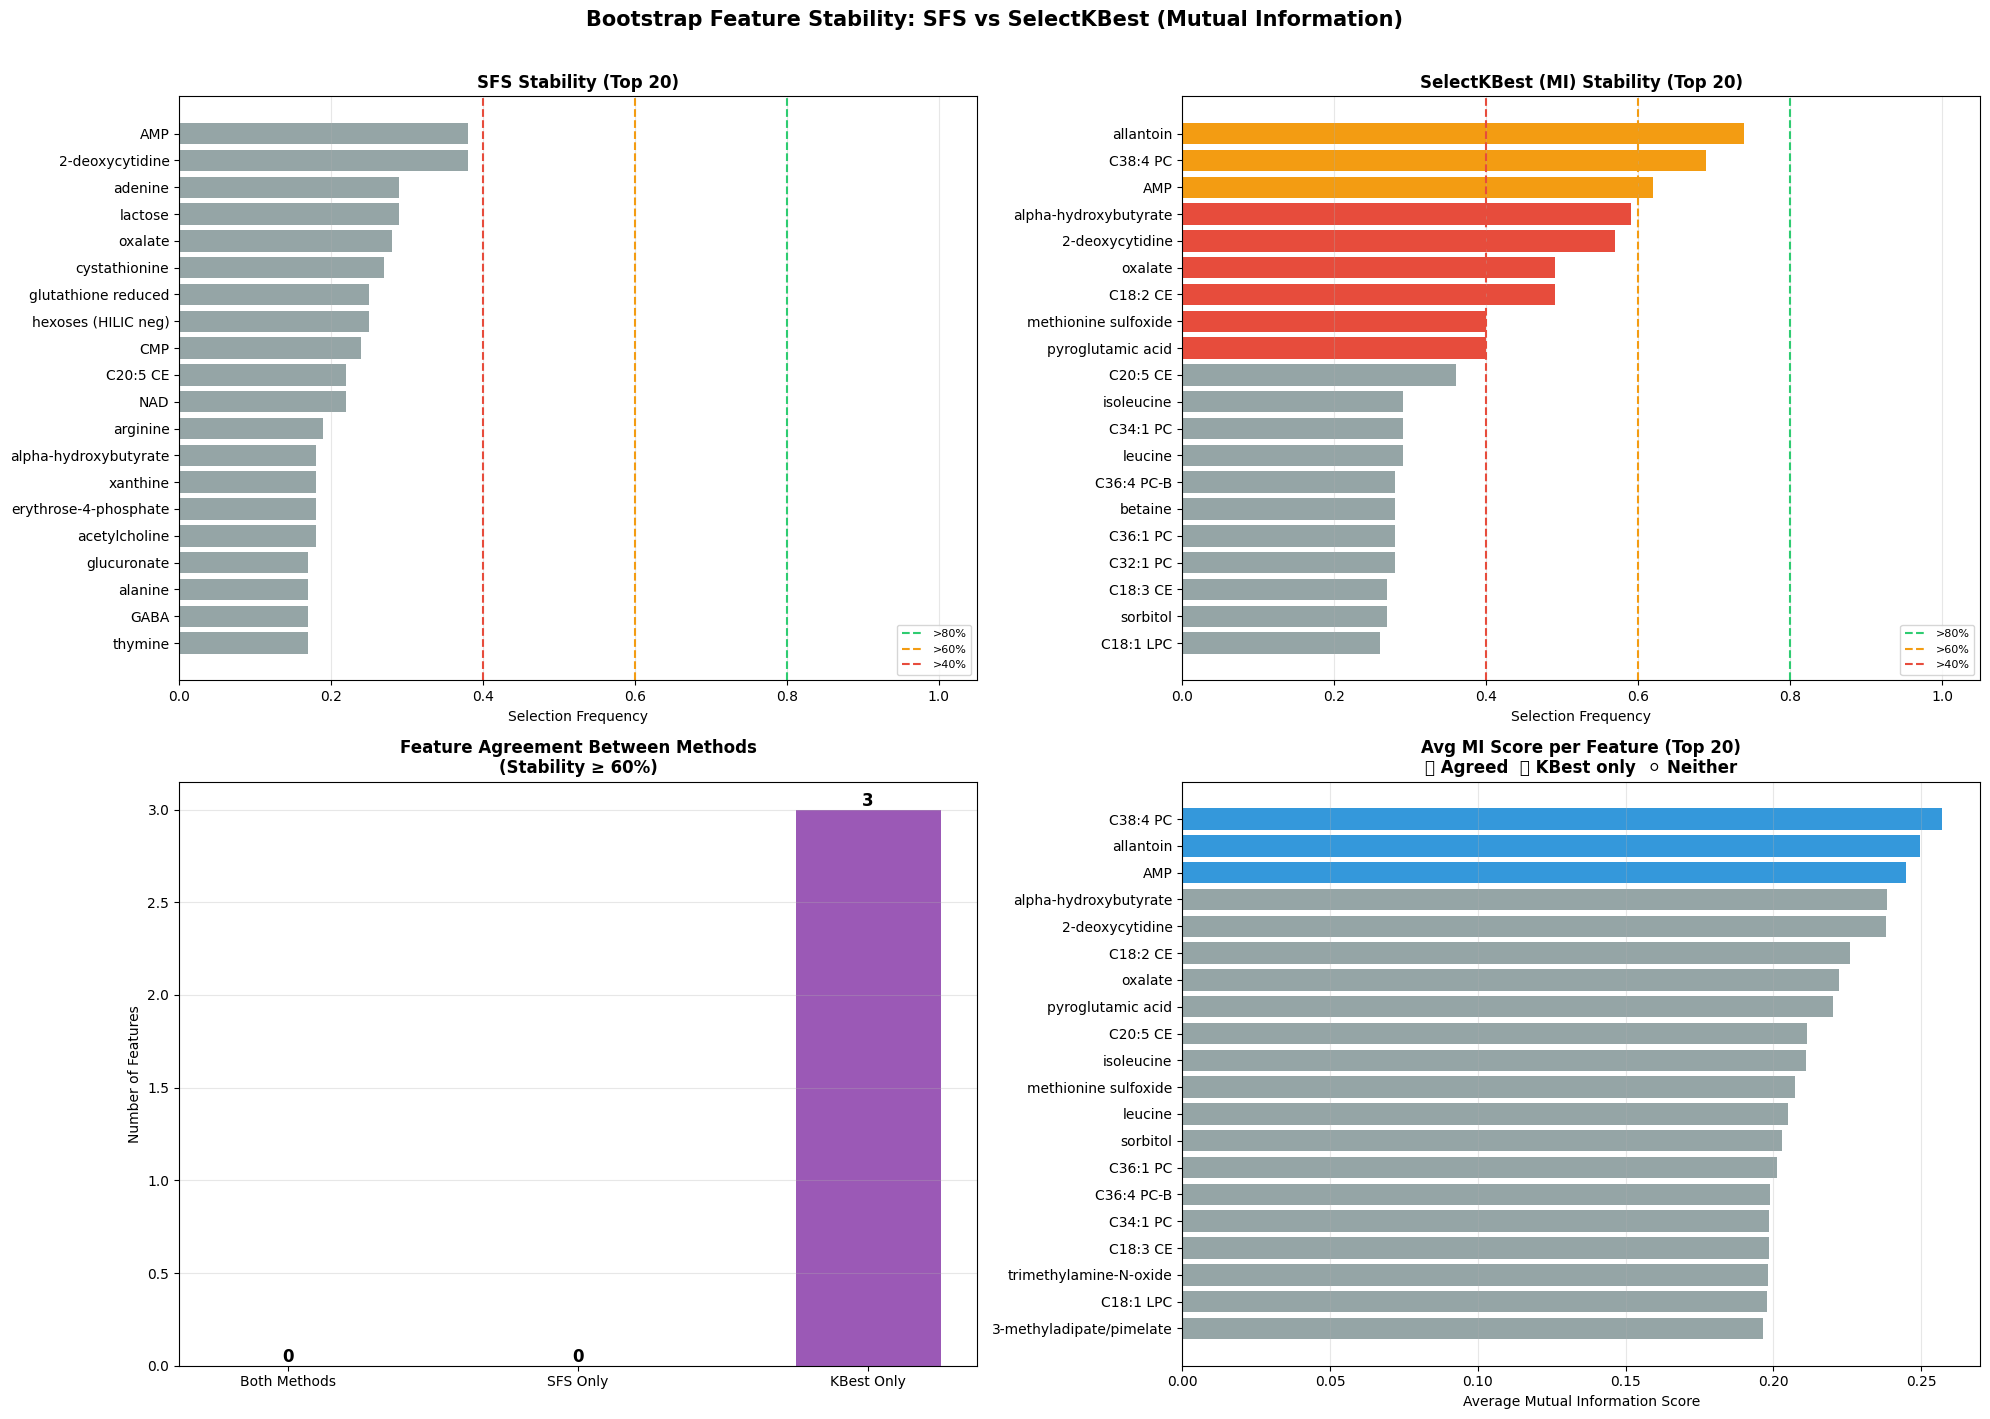

📊 Plot saved as 'bootstrap_stability_comparison.png'


In [4]:
def bootstrap_sfs_stability(df, n_iterations=100, sample_fraction=0.8, 
                             random_seed=42, k_best=20):
    """
    Runs SFS + SelectKBest (Mutual Information) on multiple bootstrap samples
    and measures feature selection stability for both methods.
    
    Parameters:
        df              : Full dataframe (df_can)
        n_iterations    : Number of bootstrap iterations (100+ recommended)
        sample_fraction : Fraction of data to sample each iteration
        random_seed     : For reproducibility
        k_best          : Number of top features to select with SelectKBest
    
    Returns:
        df_stability_sfs : Stability DataFrame for SFS
        df_stability_kbest: Stability DataFrame for SelectKBest
        all_runs_sfs     : Selected features per run (SFS)
        all_runs_kbest   : Selected features per run (KBest)
        scores_sfs       : CV scores per run (SFS)
        mi_scores_accum  : Accumulated MI scores per feature across runs
    """
    
    # --- 1. Prepare X and y ---
    X = df.drop(['depmap_id', 'cell_line_display_name', 'lineage_1', 
                 'lineage_2', 'lineage_3', 'lineage_4', 'lineage_5', 'lineage_6'], axis=1)
    y = df['lineage_2']
    
    feature_names = X.columns.tolist()
    
    # Counters for both methods
    feature_counts_sfs   = Counter()
    feature_counts_kbest = Counter()
    all_runs_sfs         = []
    all_runs_kbest       = []
    scores_sfs           = []
    mi_scores_accum      = np.zeros(len(feature_names))  # Accumulated MI scores
    
    np.random.seed(random_seed)
    successful_runs = 0
    
    # --- 2. Bootstrap Loop ---
    for i in range(n_iterations):
        print(f"  Bootstrap iteration {i+1}/{n_iterations}...", end="\r")
        
        # Resample WITH replacement
        X_boot, y_boot = resample(
            X, y,
            replace=True,
            n_samples=int(len(X) * sample_fraction),
            random_state=random_seed + i
        )
        
        # Scale INSIDE the loop to avoid data leakage
        scaler = StandardScaler()
        X_boot_scaled = scaler.fit_transform(X_boot)
        
        try:
            # =============================================
            # METHOD 1: SFS (your existing pipeline)
            # =============================================
            knn = KNeighborsClassifier(n_neighbors=3)
            sfs = SFS(knn,
                      k_features=(1, 30),
                      forward=True,
                      floating=True,
                      verbose=0,
                      scoring='accuracy',
                      cv=5)
            
            sfs.fit(X_boot_scaled, y_boot)
            
            selected_indices_sfs = list(sfs.k_feature_idx_)
            selected_features_sfs = [feature_names[j] for j in selected_indices_sfs]
            
            feature_counts_sfs.update(selected_features_sfs)
            all_runs_sfs.append(selected_features_sfs)
            scores_sfs.append(sfs.k_score_)
            
            # =============================================
            # METHOD 2: SelectKBest + Mutual Information
            # =============================================
            selector = SelectKBest(score_func=mutual_info_classif, k=k_best)
            selector.fit(X_boot_scaled, y_boot)
            
            # Accumulate raw MI scores (averaged across runs at the end)
            mi_scores_accum += selector.scores_
            
            # Get selected feature names
            selected_mask_kbest   = selector.get_support()
            selected_features_kbest = [feature_names[j] for j, selected 
                                       in enumerate(selected_mask_kbest) if selected]
            
            feature_counts_kbest.update(selected_features_kbest)
            all_runs_kbest.append(selected_features_kbest)
            
            successful_runs += 1
            
        except Exception as e:
            print(f"\n  Warning: Iteration {i+1} failed — {e}")
            continue
    
    print(f"\n✅ Bootstrap complete: {successful_runs}/{n_iterations} successful runs")
    print(f"   SFS   — Mean CV score: {np.mean(scores_sfs):.4f} ± {np.std(scores_sfs):.4f}")
    print(f"   KBest — Avg MI scores computed across {successful_runs} runs")
    
    # --- 3. Build Stability DataFrames ---
    def build_stability_df(feature_counts, n_runs):
        df_stab = pd.DataFrame({
            'feature': list(feature_counts.keys()),
            'selection_count': list(feature_counts.values())
        })
        df_stab['selection_frequency'] = df_stab['selection_count'] / n_runs
        df_stab = df_stab.sort_values('selection_frequency', ascending=False).reset_index(drop=True)
        df_stab['stability'] = pd.cut(
            df_stab['selection_frequency'],
            bins=[0, 0.4, 0.6, 0.8, 1.01],
            labels=['Unstable (<40%)', 'Moderate (40–60%)', 'Stable (60–80%)', 'Very Stable (>80%)']
        )
        return df_stab
    
    df_stability_sfs   = build_stability_df(feature_counts_sfs,   successful_runs)
    df_stability_kbest = build_stability_df(feature_counts_kbest, successful_runs)
    
    # Add average MI score to kbest df
    avg_mi_scores = mi_scores_accum / successful_runs
    mi_score_map  = dict(zip(feature_names, avg_mi_scores))
    df_stability_kbest['avg_mi_score'] = df_stability_kbest['feature'].map(mi_score_map)
    
    return df_stability_sfs, df_stability_kbest, all_runs_sfs, all_runs_kbest, scores_sfs, mi_score_map


def plot_bootstrap_stability(df_stability_sfs, df_stability_kbest, mi_score_map, top_n=20):
    """
    4-panel plot comparing SFS and SelectKBest bootstrap stability,
    plus their agreement and MI score distribution.
    """
    
    def get_color(freq):
        if freq >= 0.80:   return '#2ecc71'
        elif freq >= 0.60: return '#f39c12'
        elif freq >= 0.40: return '#e74c3c'
        else:              return '#95a5a6'

    fig, axes = plt.subplots(2, 2, figsize=(20, 14))
    fig.suptitle('Bootstrap Feature Stability: SFS vs SelectKBest (Mutual Information)',
                 fontsize=15, fontweight='bold', y=1.01)
    
    # --- Panel 1: SFS Stability ---
    df_sfs_plot = df_stability_sfs.head(top_n).copy()
    colors_sfs  = df_sfs_plot['selection_frequency'].apply(get_color).tolist()
    axes[0,0].barh(df_sfs_plot['feature'][::-1], df_sfs_plot['selection_frequency'][::-1],
                   color=colors_sfs[::-1])
    for thresh, col, lbl in [(0.80, '#2ecc71', '>80%'), (0.60, '#f39c12', '>60%'), (0.40, '#e74c3c', '>40%')]:
        axes[0,0].axvline(x=thresh, color=col, linestyle='--', linewidth=1.5, label=lbl)
    axes[0,0].set_xlabel('Selection Frequency')
    axes[0,0].set_title(f'SFS Stability (Top {top_n})', fontweight='bold')
    axes[0,0].legend(loc='lower right', fontsize=8)
    axes[0,0].set_xlim(0, 1.05)
    axes[0,0].grid(axis='x', alpha=0.3)
    
    # --- Panel 2: SelectKBest Stability ---
    df_kbest_plot = df_stability_kbest.head(top_n).copy()
    colors_kbest  = df_kbest_plot['selection_frequency'].apply(get_color).tolist()
    axes[0,1].barh(df_kbest_plot['feature'][::-1], df_kbest_plot['selection_frequency'][::-1],
                   color=colors_kbest[::-1])
    for thresh, col, lbl in [(0.80, '#2ecc71', '>80%'), (0.60, '#f39c12', '>60%'), (0.40, '#e74c3c', '>40%')]:
        axes[0,1].axvline(x=thresh, color=col, linestyle='--', linewidth=1.5, label=lbl)
    axes[0,1].set_xlabel('Selection Frequency')
    axes[0,1].set_title(f'SelectKBest (MI) Stability (Top {top_n})', fontweight='bold')
    axes[0,1].legend(loc='lower right', fontsize=8)
    axes[0,1].set_xlim(0, 1.05)
    axes[0,1].grid(axis='x', alpha=0.3)
    
    # --- Panel 3: Agreement — features selected by BOTH methods ---
    stable_sfs   = set(df_stability_sfs[df_stability_sfs['selection_frequency'] >= 0.60]['feature'])
    stable_kbest = set(df_stability_kbest[df_stability_kbest['selection_frequency'] >= 0.60]['feature'])
    agreed       = stable_sfs & stable_kbest
    only_sfs     = stable_sfs - stable_kbest
    only_kbest   = stable_kbest - stable_sfs
    
    agreement_data  = {'Both Methods': len(agreed),
                       'SFS Only':     len(only_sfs),
                       'KBest Only':   len(only_kbest)}
    bar_colors = ['#2ecc71', '#3498db', '#9b59b6']
    bars = axes[1,0].bar(agreement_data.keys(), agreement_data.values(), color=bar_colors, width=0.5)
    axes[1,0].bar_label(bars, fontsize=12, fontweight='bold')
    axes[1,0].set_title('Feature Agreement Between Methods\n(Stability ≥ 60%)', fontweight='bold')
    axes[1,0].set_ylabel('Number of Features')
    axes[1,0].grid(axis='y', alpha=0.3)
    
    # Annotate agreed features
    if agreed:
        agreed_text = '\n'.join(sorted(agreed)[:15])
        axes[1,0].text(0, max(agreement_data.values()) * 0.5, 
                       f"Agreed features:\n{agreed_text}",
                       fontsize=7, va='center', ha='center',
                       bbox=dict(boxstyle='round', facecolor='#eafaf1', alpha=0.8))
    
    # --- Panel 4: Average MI Score (top features) ---
    mi_df = pd.DataFrame({'feature': list(mi_score_map.keys()),
                          'avg_mi_score': list(mi_score_map.values())})
    mi_df = mi_df.sort_values('avg_mi_score', ascending=False).head(top_n)
    mi_colors = ['#2ecc71' if f in agreed else '#3498db' if f in stable_kbest 
                 else '#95a5a6' for f in mi_df['feature']]
    
    axes[1,1].barh(mi_df['feature'][::-1], mi_df['avg_mi_score'][::-1], color=mi_colors[::-1])
    axes[1,1].set_xlabel('Average Mutual Information Score')
    axes[1,1].set_title(f'Avg MI Score per Feature (Top {top_n})\n🟢 Agreed  🔵 KBest only  ⚪ Neither',
                        fontweight='bold')
    axes[1,1].grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('bootstrap_stability_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("📊 Plot saved as 'bootstrap_stability_comparison.png'")


# ============================================================
# RUN THE ANALYSIS
# ============================================================

(df_stability_sfs, df_stability_kbest, 
 all_runs_sfs, all_runs_kbest, 
 scores_sfs, mi_score_map) = bootstrap_sfs_stability(
    df_can,
    n_iterations=100,
    sample_fraction=0.8,
    random_seed=42,
    k_best=20          # Number of features SelectKBest picks each run
)

# --- Summary tables ---
print("\n📋 SFS — Top 15 most stable features:")
print(df_stability_sfs.head(15).to_string(index=False))

print("\n📋 SelectKBest (MI) — Top 15 most stable features:")
print(df_stability_kbest.head(15).to_string(index=False))

# --- Cross-method agreement ---
stable_sfs   = set(df_stability_sfs[df_stability_sfs['selection_frequency'] >= 0.80]['feature'])
stable_kbest = set(df_stability_kbest[df_stability_kbest['selection_frequency'] >= 0.80]['feature'])
agreed       = stable_sfs & stable_kbest

print(f"\n🏆 GOLD STANDARD — Features stable in BOTH methods (>80%):")
print(sorted(agreed) if agreed else "  None at 80% threshold — try lowering to 60%")

# --- Plots ---
plot_bootstrap_stability(df_stability_sfs, df_stability_kbest, mi_score_map, top_n=20)

Clases detectadas: ['Lung Neuroendocrine Tumor' 'Non-Small Cell Lung Cancer']


c:\Users\ibane\anaconda3\envs\compu2\Lib\site-packages\xgboost\training.py:200: UserWarning: [17:47:30] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



--- REPORTE DE CLASIFICACIÓN ---
                            precision    recall  f1-score   support

 Lung Neuroendocrine Tumor       1.00      0.60      0.75        10
Non-Small Cell Lung Cancer       0.86      1.00      0.92        24

                  accuracy                           0.88        34
                 macro avg       0.93      0.80      0.84        34
              weighted avg       0.90      0.88      0.87        34



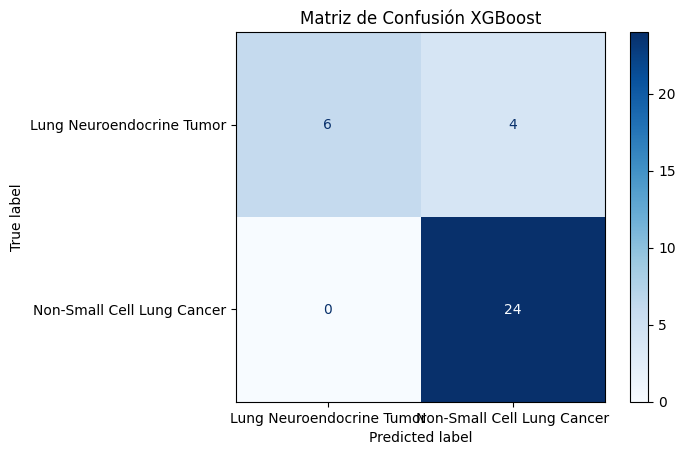

<Figure size 1000x800 with 0 Axes>

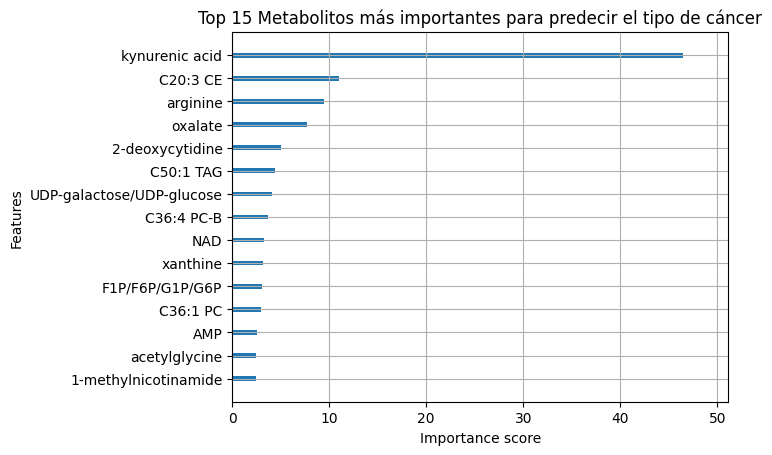

In [7]:
# ---------------------------------------------------------
# PASO 1: Separar las Features (X) y el Target (y)
# ---------------------------------------------------------
# X serán todos los metabolitos (eliminamos la columna del tipo de cáncer para que la IA no haga trampa)

metabolitos = df_can.drop(['depmap_id', 'cell_line_display_name', 'lineage_1', 
                 'lineage_2', 'lineage_3', 'lineage_4', 'lineage_5', 'lineage_6'], axis=1)

X = metabolitos

# y será nuestra variable a predecir (el tipo de cáncer)
y_raw = df_can['lineage_2']

# ---------------------------------------------------------
# PASO 2: Codificar el Target (y) a números
# ---------------------------------------------------------
# XGBoost necesita que si tienes "CancerA", "CancerB", se conviertan en 0 y 1.
le = LabelEncoder()
y = le.fit_transform(y_raw)

# Para no olvidar qué número es qué cáncer, guardamos los nombres reales:
nombres_clases = le.classes_
print("Clases detectadas:", nombres_clases)

# ---------------------------------------------------------
# PASO 3: Dividir en Entrenamiento (Train) y Prueba (Test)
# ---------------------------------------------------------
# Usamos el 80% para entrenar y el 20% para examinar al modelo.
# 'stratify=y' es vital en medicina: asegura que la misma proporción de tipos de cáncer vaya a train y a test.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ---------------------------------------------------------
# PASO 4: Crear y Entrenar el modelo XGBoost
# ---------------------------------------------------------
# Inicializamos el clasificador
modelo_xgb = xgb.XGBClassifier(
    random_state=42, 
    eval_metric='mlogloss', # Métrica de evaluación interna
    use_label_encoder=False # Evita una advertencia común de XGBoost
)

# ¡Entrenamos la IA!
modelo_xgb.fit(X_train, y_train)

# ---------------------------------------------------------
# PASO 5: Predicciones y Evaluación
# ---------------------------------------------------------
# Le pedimos al modelo que prediga los pacientes que nunca ha visto (X_test)
y_pred = modelo_xgb.predict(X_test)

# Mostramos los resultados
print("\n--- REPORTE DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=nombres_clases))

# Dibujar la Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp.plot(cmap=plt.cm.Blues)
plt.title("Matriz de Confusión XGBoost")
plt.show()

# ---------------------------------------------------------
# PASO 6: Descubrir los Biomarcadores (Feature Importance)
# ---------------------------------------------------------
# ¿Qué metabolitos usó XGBoost para decidir el tipo de cáncer?
plt.figure(figsize=(10, 8))
# Mostramos solo los top 15 metabolitos más importantes
xgb.plot_importance(modelo_xgb, max_num_features=15, importance_type='gain', show_values=False)
plt.title("Top 15 Metabolitos más importantes para predecir el tipo de cáncer")
plt.show()

# RFECV

Buscando el mejor conjunto de metabolitos. Esto puede tardar un momento...

¡Búsqueda completada!
El número óptimo de metabolitos es: 15

--- EL MEJOR CONJUNTO DE METABOLITOS (PANEL ÓPTIMO) ---
1. AMP
2. F1P/F6P/G1P/G6P
3. NAD
4. oxalate
5. UDP-galactose/UDP-glucose
6. arginine
7. acetylglycine
8. kynurenic acid
9. 2-deoxycytidine
10. oleylcarnitine
11. C36:4 PC-B
12. C36:1 PC
13. C22:0 SM
14. C20:3 CE
15. C50:1 TAG


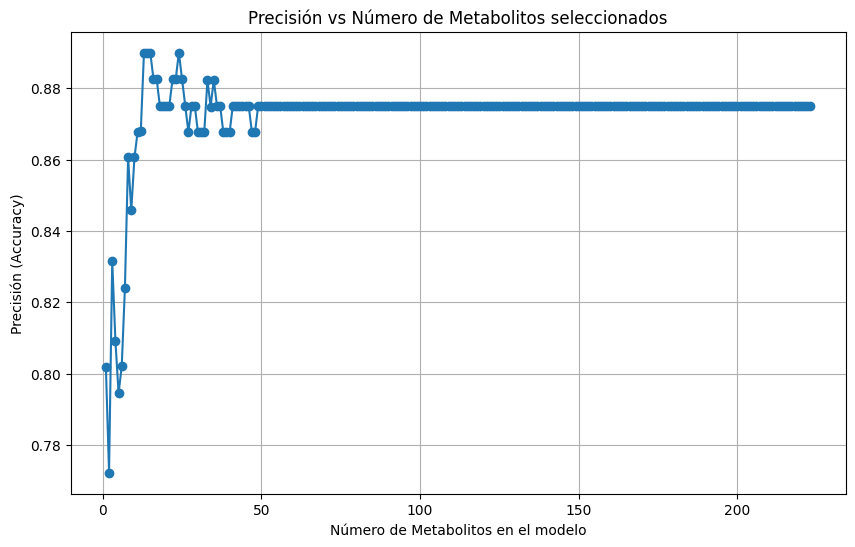

In [8]:
# 1. Usamos el mismo modelo XGBoost base
modelo_base = xgb.XGBClassifier(
    random_state=42, 
    eval_metric='mlogloss',
    verbosity=0 
)

# 2. Configuramos la validación cruzada (StratifiedKFold asegura equilibrio en las clases de cáncer)
cv = StratifiedKFold(n_splits=5) # Divide los datos en 5 partes para probar

# 3. Configuramos el RFECV
# step=1: elimina 1 metabolito en cada ronda (si tienes miles, pon step=5 para ir más rápido)
# min_features_to_select: el número mínimo de metabolitos que quieres en tu panel final
selector = RFECV(
    estimator=modelo_base, 
    step=1, 
    cv=cv, 
    scoring='accuracy', # Busca maximizar la precisión global
    min_features_to_select=3,
    n_jobs=-1 # Usa todos los núcleos de tu PC para ir más rápido
)

print("Buscando el mejor conjunto de metabolitos. Esto puede tardar un momento...")
# 4. Ejecutamos la búsqueda en nuestros datos de entrenamiento
selector.fit(X_train, y_train)

# 5. Extraer los resultados
numero_optimo = selector.n_features_
metabolitos_optimos = X_train.columns[selector.support_].tolist()

print(f"\n¡Búsqueda completada!")
print(f"El número óptimo de metabolitos es: {numero_optimo}")
print("\n--- EL MEJOR CONJUNTO DE METABOLITOS (PANEL ÓPTIMO) ---")
for i, met in enumerate(metabolitos_optimos, 1):
    print(f"{i}. {met}")

# 6. Gráfico para ver cómo cambia la precisión según la cantidad de metabolitos
plt.figure(figsize=(10, 6))
plt.title('Precisión vs Número de Metabolitos seleccionados')
plt.xlabel('Número de Metabolitos en el modelo')
plt.ylabel('Precisión (Accuracy)')
# cv_results_['mean_test_score'] contiene la precisión en cada paso
plt.plot(range(1, len(selector.cv_results_['mean_test_score']) + 1), selector.cv_results_['mean_test_score'], marker='o')
plt.grid(True)
plt.show()

# Ignorar todos los warnings de tipo "FutureWarning", "UserWarning", etc.
warnings.filterwarnings('ignore')

# (Opcional) Si te sale un warning específico de Pandas sobre copias, esto lo apaga:

pd.options.mode.chained_assignment = None

# XGBOOST SCALE POS

--- DISTRIBUCIÓN DE ENTRENAMIENTO ---
Clase 0 (NSCLC - Mayoría): 96 pacientes
Clase 1 (LNET - Minoría): 40 pacientes
Valor de scale_pos_weight calculado: 2.40

--- NUEVO REPORTE DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

   NSCLC (0)       0.95      0.88      0.91        24
    LNET (1)       0.75      0.90      0.82        10

    accuracy                           0.88        34
   macro avg       0.85      0.89      0.87        34
weighted avg       0.89      0.88      0.89        34



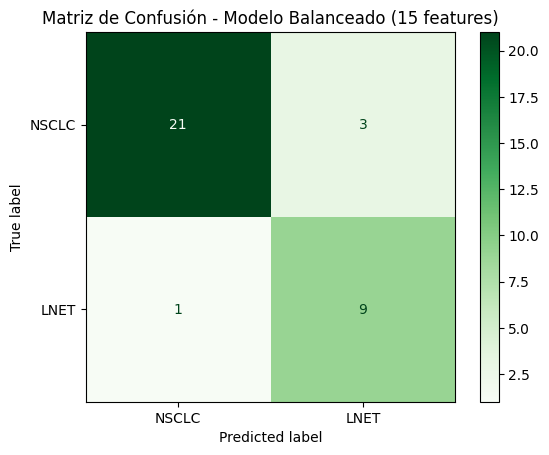

In [10]:

# 1. Tu lista del panel óptimo (los 15 metabolitos)
metabolitos_optimos = [
    'AMP', 'F1P/F6P/G1P/G6P', 'NAD', 'oxalate', 'UDP-galactose/UDP-glucose',
    'arginine', 'acetylglycine', 'kynurenic acid', '2-deoxycytidine',
    'oleylcarnitine', 'C36:4 PC-B', 'C36:1 PC', 'C22:0 SM', 'C20:3 CE', 'C50:1 TAG'
]

# 2. Creamos el sub-dataset solo con las columnas ganadoras
X_final = metabolitos[metabolitos_optimos]
y_raw = df_can['lineage_2']

# 3. ¡EL TRUCO! Mapeamos manualmente para que la IA sepa qué buscar
# LNET (minoría) = 1 (La clase "Positiva")
# NSCLC (mayoría) = 0 (La clase "Negativa")
y_final = y_raw.map({'Lung Neuroendocrine Tumor': 1, 'Non-Small Cell Lung Cancer': 0})

# 4. Dividir en Entrenamiento y Prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y_final, test_size=0.2, random_state=42, stratify=y_final
)

# 5. CALCULAR EL SCALE_POS_WEIGHT
# La fórmula oficial de XGBoost es: count(negativos) / count(positivos)
negativos = (y_train == 0).sum() # Cuántos NSCLC hay en train
positivos = (y_train == 1).sum() # Cuántos LNET hay en train
peso = negativos / positivos

print(f"--- DISTRIBUCIÓN DE ENTRENAMIENTO ---")
print(f"Clase 0 (NSCLC - Mayoría): {negativos} pacientes")
print(f"Clase 1 (LNET - Minoría): {positivos} pacientes")
print(f"Valor de scale_pos_weight calculado: {peso:.2f}\n")

# 6. Crear el modelo aplicando el peso
modelo_balanceado = xgb.XGBClassifier(
    random_state=42, 
    eval_metric='logloss',
    scale_pos_weight=peso  # <--- AQUÍ ESTÁ LA MAGIA
)

# 7. Entrenar el modelo
modelo_balanceado.fit(X_train, y_train)

# 8. Evaluar
y_pred = modelo_balanceado.predict(X_test)

print("--- NUEVO REPORTE DE CLASIFICACIÓN ---")
# Le pasamos los nombres explícitos para que el reporte sea fácil de leer
nombres_clases = ['NSCLC (0)', 'LNET (1)']
print(classification_report(y_test, y_pred, target_names=nombres_clases))

# 9. Mostrar la nueva Matriz de Confusión
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['NSCLC', 'LNET'])
disp.plot(cmap=plt.cm.Greens) # Cambié a verde para diferenciarlo de tu modelo anterior
plt.title("Matriz de Confusión - Modelo Balanceado (15 features)")
plt.show()